In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

df = pd.read_csv("city_day.csv")

df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [5]:
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


,0
City,0
Date,0
PM2.5,4598
PM10,11140
NO,3582
NO2,3585
NOx,4185
NH3,10328
CO,2059
SO2,3854


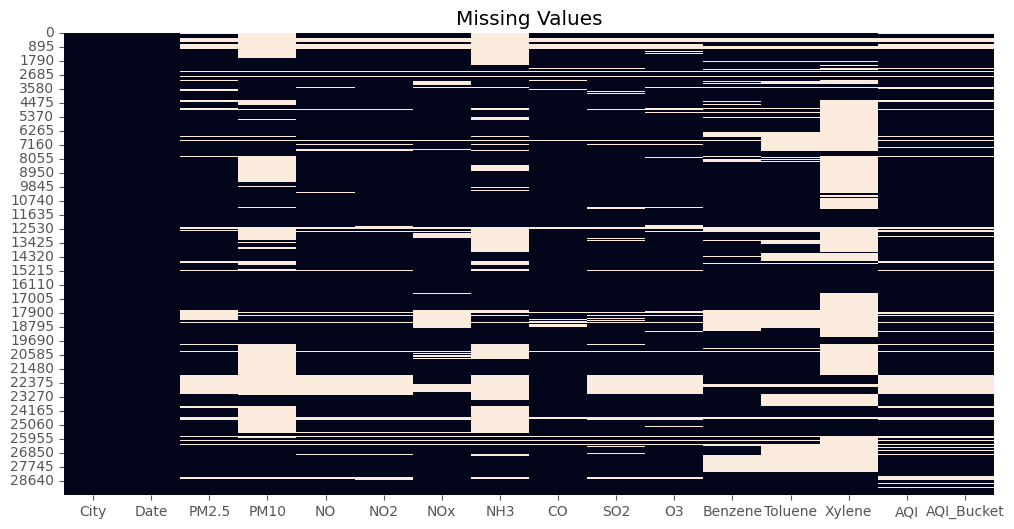

In [6]:
plt.figure(figsize=(12,6))

sns.heatmap(df.isnull(),
            cbar=False)

plt.title("Missing Values")
plt.show()

The dataset contains substantial missing values because air quality sensors occasionally fail or undergo maintenance.

Instead of deleting rows and losing valuable information, interpolation was used for continuous variables.


In [9]:
columns = [
    "PM2.5",
    "PM10",
    "NO",
    "NO2",
    "CO",
    "SO2",
    "AQI"
]

df[columns] = df[columns].interpolate()

df.dropna(inplace=True)

df["Date"] = pd.to_datetime(df["Date"])

df["Year"] = df["Date"].dt.year

df["Month"] = df["Date"].dt.month

df["Day"] = df["Date"].dt.day

df["Weekday"] = df["Date"].dt.day_name()

df["Season"] = df["Month"].map({
    12:"Winter",
    1:"Winter",
    2:"Winter",

    3:"Summer",
    4:"Summer",
    5:"Summer",

    6:"Monsoon",
    7:"Monsoon",
    8:"Monsoon",
    9:"Monsoon",

    10:"Post-Monsoon",
    11:"Post-Monsoon"
})

Text(0, 0.5, 'AQI')

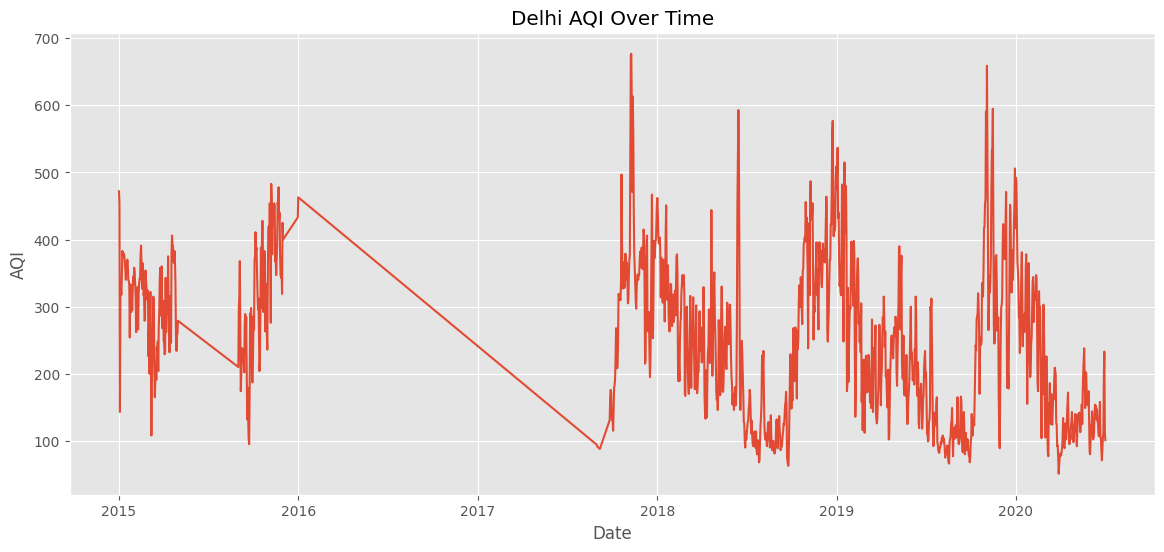

In [10]:
delhi = df[df["City"]=="Delhi"]

plt.figure(figsize=(14,6))

plt.plot(delhi["Date"],delhi["AQI"])

plt.title("Delhi AQI Over Time")

plt.xlabel("Date")

plt.ylabel("AQI")

AQI increases sharply during October and November, corresponding to post-monsoon crop residue burning and cooler atmospheric conditions.


([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, 'Amaravati'),
  Text(1, 0, 'Amritsar'),
  Text(2, 0, 'Chandigarh'),
  Text(3, 0, 'Delhi'),
  Text(4, 0, 'Gurugram'),
  Text(5, 0, 'Hyderabad'),
  Text(6, 0, 'Kolkata'),
  Text(7, 0, 'Patna'),
  Text(8, 0, 'Visakhapatnam')])

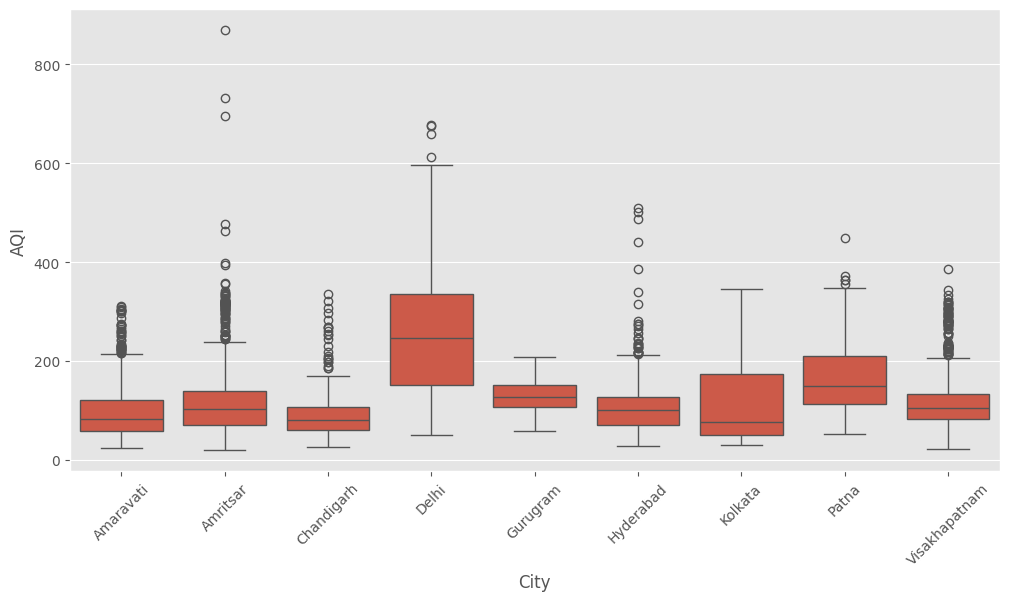

In [11]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df,
            x="City",
            y="AQI")

plt.xticks(rotation=45)

Conclusion

Delhi has the highest AQI median.

Bengaluru remains comparatively cleaner.

<Axes: xlabel='City', ylabel='Month'>

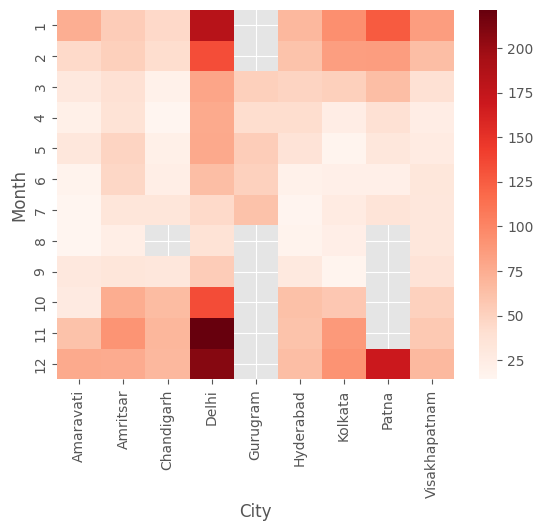

In [12]:
pivot = df.pivot_table(
    values="PM2.5",
    index="Month",
    columns="City",
    aggfunc="mean"
)

sns.heatmap(pivot,
            cmap="Reds")

<Axes: xlabel='Season', ylabel='AQI'>

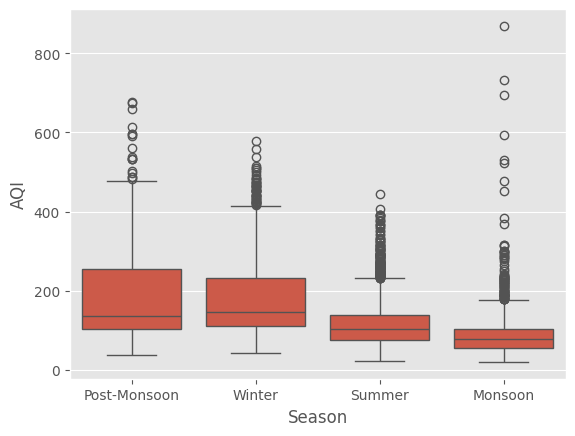

In [13]:
sns.boxplot(
    data=df,
    x="Season",
    y="AQI"
)

Conclusion

Winter records the worst air quality across nearly every city.

<Axes: >

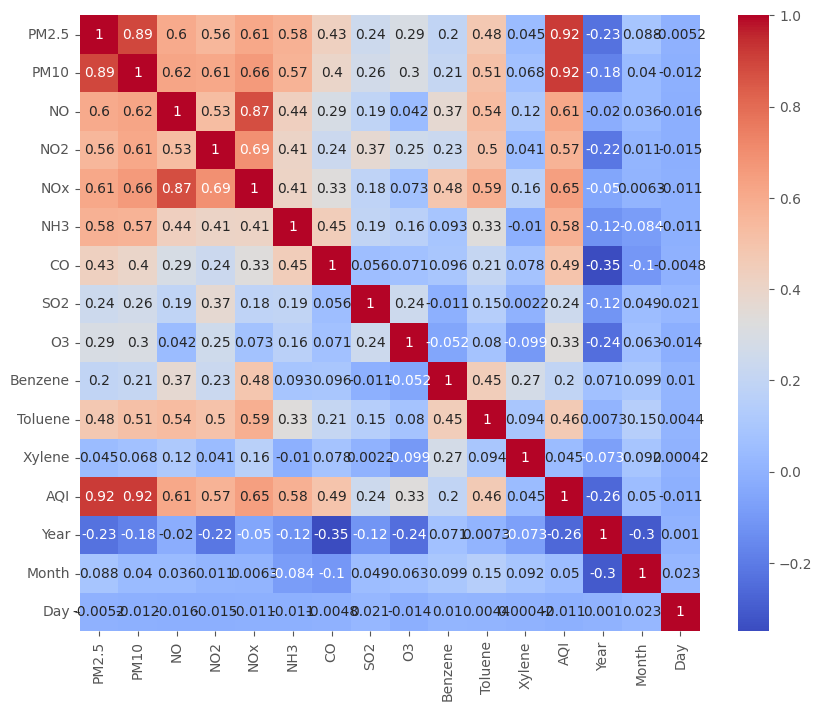

In [14]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

Interesting finding

PM2.5 and AQI are highly correlated.

<Axes: ylabel='City'>

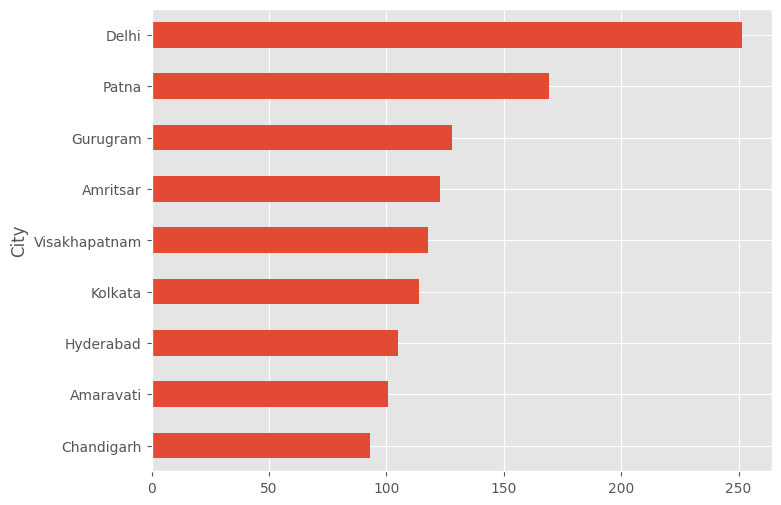

In [15]:
city_mean = df.groupby("City")["AQI"].mean()

city_mean.sort_values().plot.barh(figsize=(8,6))

## Key Insights

1. Delhi consistently recorded the highest AQI among the studied cities.

2. Winter months showed significantly worse pollution levels due to lower temperatures and crop residue burning.

3. PM2.5 demonstrated the strongest positive correlation with AQI, making it the most influential pollutant.

4. Interpolation successfully recovered missing sensor observations while preserving temporal continuity.

5. Bengaluru and Chennai exhibited comparatively lower pollution levels throughout the study period.